In [1]:
import seaborn as sns
df = sns.load_dataset("titanic")


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [3]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.shape

(891, 15)

In [5]:
df.isnull().mean()*100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [6]:
df.to_csv("titanic.csv", index=False)

In [7]:
# Check missing percentages
missing_percentage = (df.isnull().mean() * 100).round(2)

print(missing_percentage[missing_percentage > 0])

age            19.87
embarked        0.22
deck           77.22
embark_town     0.22
dtype: float64


Missing values were handled separately for each column according to the specified threshold rule.

The Embarked column had 0.22% missing values (2 out of 891 rows). Since the missing rate was below 5%, the corresponding rows were dropped.

The Embarked town column had 0.22% missing values (2 out of 891 rows). Since the missing rate was below 5%, the corresponding rows were dropped.

The Age column had 19.87% missing values (177 out of 891 rows). Since the missing rate was between 5% and 30%, the missing values were imputed using the median age. Median imputation was selected because it is less sensitive to extreme age values than mean imputation.

The Deck column had 77.10% missing values (687 out of 891 rows). Since the missing rate was substantially above 30%, directly imputing deck values would be unreliable. Instead of dropping the column, the missing values were encoded as a separate "Missing" category. This preserves the information that a deck value was not recorded, which may itself be useful for analysis or prediction.

All remaining columns had 0% missing values and therefore required no missing-value treatment.

In [8]:
# 1. Embarked: 0.22% < 5% drop rows
df = df.dropna(subset=['embarked'])
# 2. Embark_town: 0.22% < 5% drop rows
df = df.dropna(subset=['embark_town'])

# 3. Age: 19.87% in 5–30% median imputation
df['age'] = df['age'].fillna(df['age'].median())

# 4. Deck: 7.22% > 30% treat missing as its own category
df['deck'] = df['deck'].cat.add_categories(['missing'])
df['deck'] = df['deck'].fillna("missing")

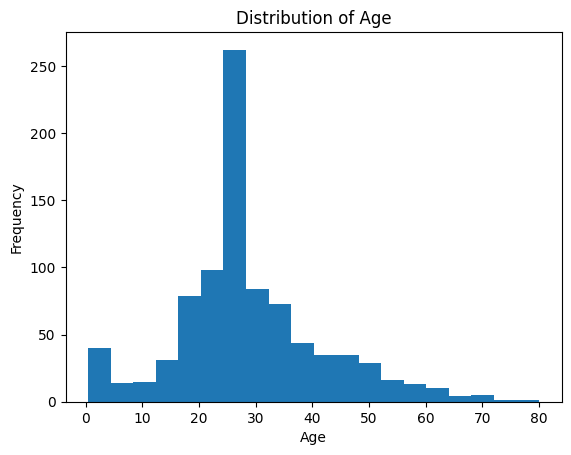

In [9]:
import matplotlib.pyplot as plt
plt.hist(df['age'].dropna(), bins=20)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

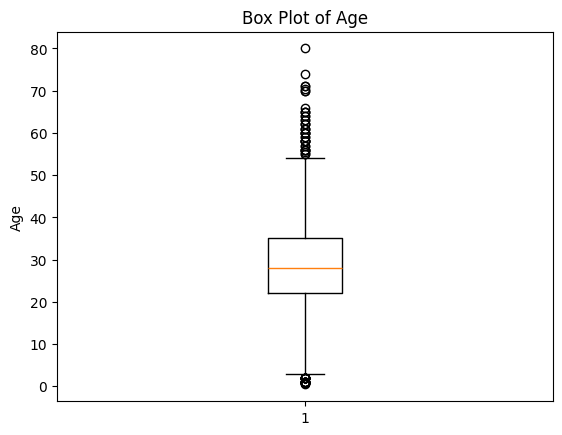

In [10]:
plt.boxplot(df['age'].dropna())
plt.ylabel('Age')
plt.title('Box Plot of Age')
plt.show()

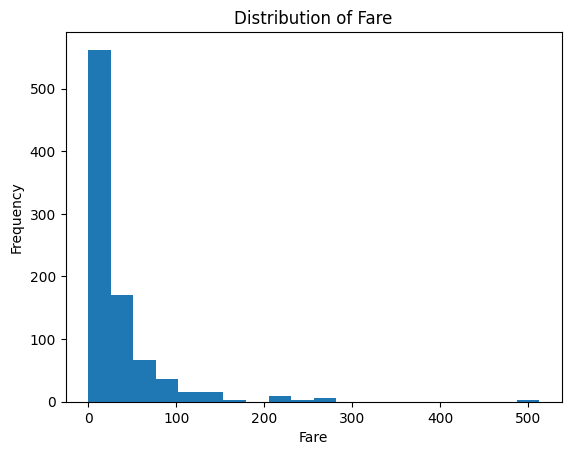

In [11]:
plt.hist(df['fare'].dropna(), bins=20)
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.title('Distribution of Fare')
plt.show()

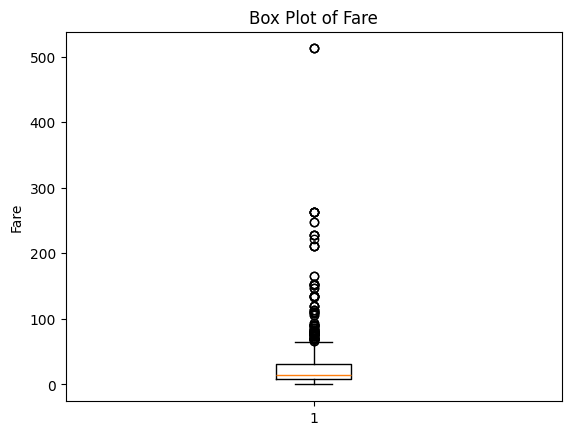

In [12]:
plt.boxplot(df['fare'].dropna())
plt.ylabel('Fare')
plt.title('Box Plot of Fare')
plt.show()

In [14]:
def find_outliers(column):
    data = df[column].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data < lower) | (data > upper)]

    print(f"{column}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower bound: {lower:.2f}")
    print(f"Upper bound: {upper:.2f}")
    print(f"Number of outliers: {len(outliers)}")
    print()

find_outliers('age')
find_outliers('fare')

age
Q1: 22.00
Q3: 35.00
IQR: 13.00
Lower bound: 2.50
Upper bound: 54.50
Number of outliers: 65

fare
Q1: 7.90
Q3: 31.00
IQR: 23.10
Lower bound: -26.76
Upper bound: 65.66
Number of outliers: 114



In [15]:
mean_fare = df['fare'].mean()
median_fare = df['fare'].median()
mode_fare = df['fare'].mode()[0]

print("Mean:", mean_fare)
print("Median:", median_fare)
print("Mode:", mode_fare)

Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05


For fare, the mean, median, and mode were approximately 32.20, 14.45, and 8.05. The ordering is Mean > Median > Mode, that the fare distribution is right-skewed (positively skewed).

In [16]:
male = df[df['sex'] == 'male']
female = df[df['sex'] == 'female']

In [17]:
print("Male survival rate:", male['survived'].mean() * 100)
print("Female survival rate:", female['survived'].mean() * 100)

Male survival rate: 18.890814558058924
Female survival rate: 74.03846153846155


In [18]:
first = df.loc[df['pclass'] == 1, 'survived'].mean() * 100
second = df.loc[df['pclass'] == 2, 'survived'].mean() * 100
third = df.loc[df['pclass'] == 3, 'survived'].mean() * 100

In [ ]:
print("1st class:", first)
print("2nd class:", second)
print("3rd class:", third)

1st class: 62.616822429906534
2nd class: 47.28260869565217
3rd class: 24.236252545824847


In [20]:
df.groupby(['sex', 'pclass'])['survived'].mean() * 100

sex     pclass
female  1         96.739130
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: survived, dtype: float64

In [21]:
cols = [
    'survived',
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare'
]

corr = df[cols].corr()

print(corr)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


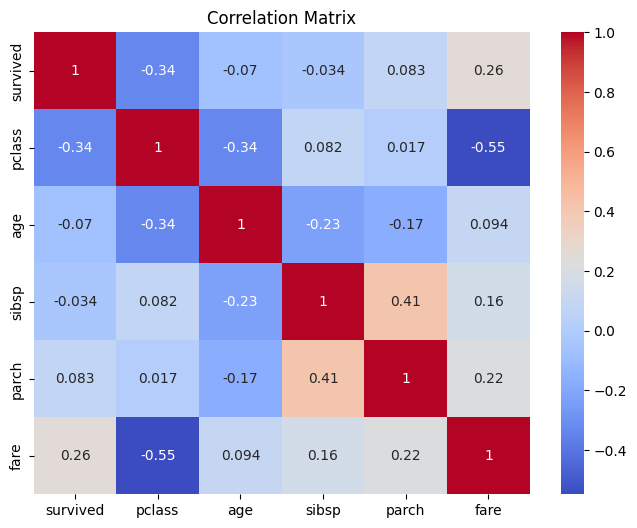

In [25]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

In [27]:
import numpy as np

In [28]:
abs_corr = corr.abs()

# Keep only upper triangle, excluding diagonal
upper = abs_corr.where(
    np.triu(np.ones(abs_corr.shape), k=1).astype(bool)
)

# Sort correlations
strongest = upper.stack().sort_values(ascending=False)

print(strongest.head(2))

pclass  fare     0.548193
sibsp   parch    0.414542
dtype: float64


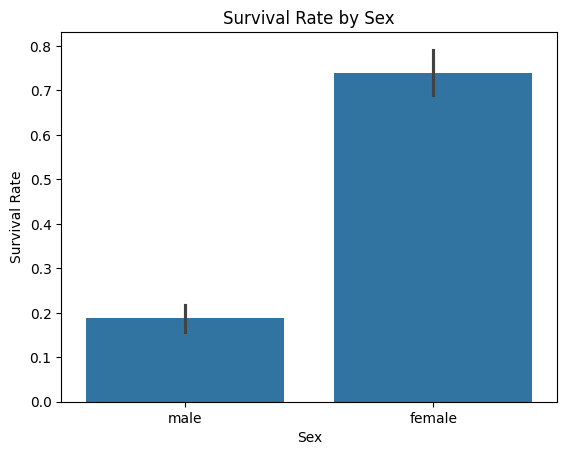

In [ ]:
sns.barplot(data=df, x='sex', y='survived')

plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()

**Survival rates differed between male and female passengers. The chart shows that the survival rate for females was higher than that for males in this dataset. This indicates that sex was strongly associated with survival outcomes**

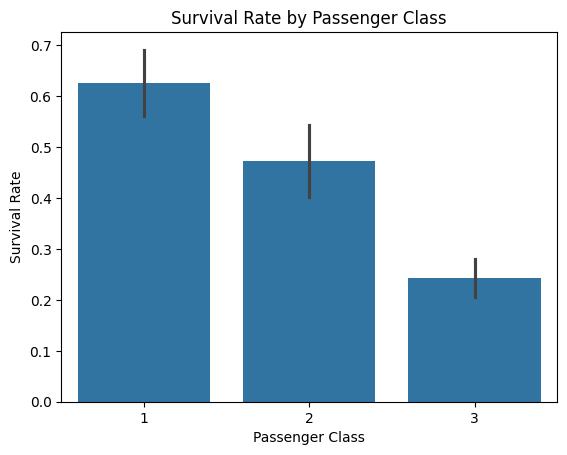

In [32]:
sns.barplot(data=df, x='pclass', y='survived')

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

**Survival rates varied across passenger classes. Passengers in first class had a higher survival rate than passengers in second and third class, while third-class passengers had the lowest rate. This suggests that passenger class was associated with survival**

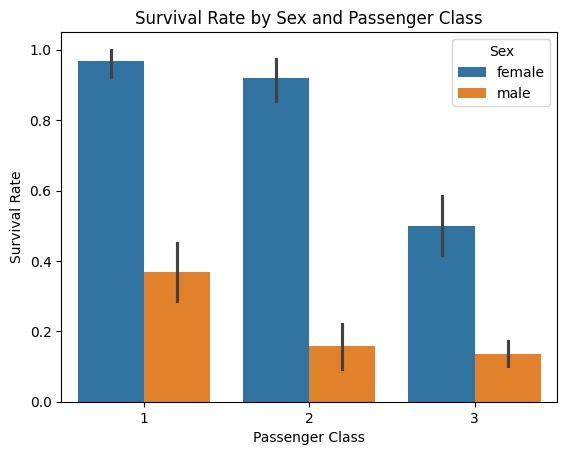

In [33]:
sns.barplot(
    data=df,
    x='pclass',
    y='survived',
    hue='sex'
)

plt.title('Survival Rate by Sex and Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.legend(title='Sex')
plt.show()

**Survival varied across both sex and passenger class. Within each passenger class, females generally had higher survival rates than males, while survival also varied across the three classes. This shows that examining sex and class together provides more detail than looking at either variable independently**

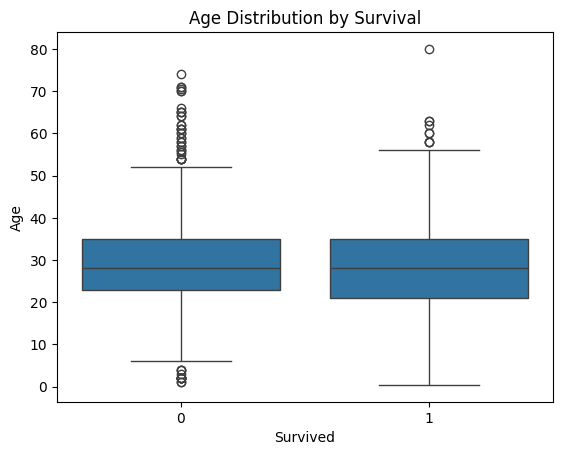

In [34]:
sns.boxplot(
    data=df,
    x='survived',
    y='age'
)

plt.title('Age Distribution by Survival')
plt.xlabel('Survived')
plt.ylabel('Age')
plt.show()

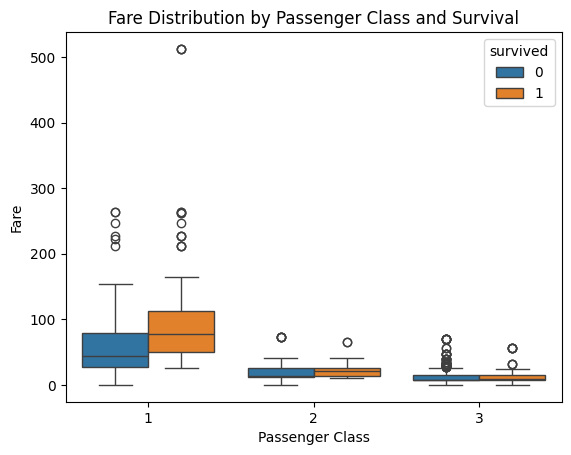

In [35]:
sns.boxplot(
    data=df,
    x='pclass',
    y='fare',
    hue='survived'
)

plt.title('Fare Distribution by Passenger Class and Survival')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

**The box plot shows that fare values vary across passenger classes, with first-class passengers generally paying higher fares than second- and third-class passengers. Within each class, the fare distributions of survivors and non-survivors also differ, with several high-fare observations appearing as outliers.**

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['age_scaled', 'fare_scaled']] = scaler.fit_transform(
    df[['age', 'fare']]
)

In [38]:
print("BEFORE STANDARDIZATION")
print(df[['age', 'fare']].agg(['mean', 'std']))

print("\nAFTER STANDARDIZATION")
print(df[['age_scaled', 'fare_scaled']].agg(['mean', 'std']))

BEFORE STANDARDIZATION
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

AFTER STANDARDIZATION
        age_scaled   fare_scaled
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00
